# ③ `stairs` — 저조도 계단 탐지는 완료됐는가

> 모델: `outputs/detect/c4b_loli0/weights/best.pt` (YOLO11n · `C4b` · 2026-08-02)
> 클래스: `person`(0) · `stairs`(1) — 단일 모델 통합

## 이 노트북이 답하는 것

수치표는 "야간 mAP50 0.993" 이라고 말한다. **그런데 그 수치가 무엇을 잰 것인지**는
표로 알 수 없다. 여기서 다섯 가지를 눈으로 확인한다.

1. **야간이 주간보다 나쁜가** — 갈라서 재고, 예측을 직접 본다
2. ★ **그 0.993 이 재고 있는 세계** — StairNet 은 *계단이 화면을 채운 사진*이다.
   박스 면적 분포로 도메인을 가시화한다
3. ★★ **야간 거리 오탐 0.2% 의 두 얼굴** — "헛보지 않는다"인가,
   **"거리 장면에서는 아예 발화하지 않는다"**인가. 임계값을 낮춰가며 가른다
4. ★★ **②를 앞단에 붙이면 오탐이 되살아난다** (0.1% → 5.7%). 무엇을 계단으로
   착각하는지 실물로 본다 — 저시력 보행자가 반드시 지나는 곳이라 안전 이슈다
5. **그래서 무엇이 검증됐고 무엇이 안 됐는가** 정리

> 근거 문서: [detection.md 8장](../docs/detection.md) · [7장](../docs/detection.md)
> 하네스: `scripts/eval_stairs_night.py` · `scripts/arm_detect_eval.py`

> ⚠️ **작업 디렉토리를 `notebooks/` 로 열 것.** 데이터 경로를 `../` 로 잡는다.
> ⚠️ 선행 실행이 필요하다 (산출물을 재사용한다):
> ```powershell
> uv run python scripts/eval_stairs_night.py
> uv run python scripts/arm_detect_eval.py
> ```

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
assert (ROOT / "scripts").is_dir(), f"작업 디렉토리를 notebooks/ 로 열 것 (현재: {Path.cwd()})"
sys.path.insert(0, str(ROOT / "scripts"))

from ultralytics import YOLO  # noqa: E402

WEIGHTS = ROOT / "outputs/detect/c4b_loli0/weights/best.pt"
STAIRS_NIGHT = ROOT / "outputs/datasets/stairs_split/night_none"
STAIRS_DAY = ROOT / "outputs/datasets/stairs_split/day_none"
NO34 = ROOT / "outputs/datasets/nightowls_split/rec34_labeled"      # 야간 거리(원본)
NO34_ARM = ROOT / "outputs/datasets/arm_detect/D1A1_bf"             # 같은 장면 + ②

for p in (WEIGHTS, STAIRS_NIGHT, STAIRS_DAY, NO34):
    assert p.exists(), f"없다: {p}\n노트북 상단의 선행 실행 명령을 먼저 돌릴 것"

PERSON, STAIRS = 0, 1
model = YOLO(str(WEIGHTS))

# --- 표시 설정 — 다른 노트북과 같은 팔레트 (문서 대조 시 혼동 방지) -----------
matplotlib.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25,
})
GT_COLOR = (60, 220, 60)        # 정답 = 초록
PRED_COLOR = (255, 200, 0)      # 예측 = 하늘색 계열 (BGR)
FP_COLOR = (0, 90, 255)         # 오탐 = 주황 (빨강은 저시력 배제 원칙상 회피)


def load_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else None


def yolo_to_xyxy(row, w, h):
    _, cx, cy, bw, bh = (float(v) for v in row.split()[:5])
    return (int((cx - bw / 2) * w), int((cy - bh / 2) * h),
            int((cx + bw / 2) * w), int((cy + bh / 2) * h))


def read_gt(label_path, w, h, cls=None):
    if not Path(label_path).is_file():
        return []
    out = []
    for row in Path(label_path).read_text(encoding="utf-8").splitlines():
        if not row.strip():
            continue
        if cls is not None and int(float(row.split()[0])) != cls:
            continue
        out.append(yolo_to_xyxy(row, w, h))
    return out


def draw(img_rgb, boxes, color, t=2, label=None):
    out = img_rgb.copy()
    for (x1, y1, x2, y2) in boxes:
        cv2.rectangle(out, (x1, y1), (x2, y2), color[::-1], t)
        if label:
            cv2.putText(out, label, (x1, max(y1 - 5, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color[::-1], 2, cv2.LINE_AA)
    return out


def grid(images, titles, ncol=4, size=2.6, suptitle=None):
    n = len(images)
    nrow = (n + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * size, nrow * size * 0.85))
    for ax, im, t in zip(np.ravel(axes), images, titles):
        ax.imshow(im); ax.set_title(t, fontsize=8); ax.axis("off"); ax.grid(False)
    for ax in np.ravel(axes)[n:]:
        ax.axis("off"); ax.grid(False)
    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
    fig.tight_layout()
    plt.show()


print(f"모델 {WEIGHTS.parent.parent.name} · 클래스 {model.names}")

모델 c4b_loli0 · 클래스 {0: 'person', 1: 'stairs'}


## 1. 야간과 주간을 갈라서 잰다

개발 val 의 `stairs` **0.988 은 야간 76장과 주간 348장을 섞은 값**이라, 야간 성능이
낮아도 주간에 묻힌다. 이 서비스의 목적이 *야간* 보행 보조이므로 섞어 재면 안 된다.

In [2]:
rows = []
for name, dst in (("night", STAIRS_NIGHT), ("day", STAIRS_DAY)):
    m = model.val(data=str(dst / "data.yaml"), imgsz=640, device=0,
                  project=str(ROOT / "outputs/detect"), name=f"nb_stairs_{name}",
                  exist_ok=True, plots=False, verbose=False)
    idx = list(m.box.ap_class_index)
    i = idx.index(STAIRS)
    n = sum(1 for _ in (dst / "images/val").glob("*"))
    rows.append((name, n, float(m.box.ap50[i]), float(m.box.ap[i]),
                 float(m.box.p[i]), float(m.box.r[i])))

print(f"{'구간':<8}{'장수':>7}{'mAP50':>10}{'mAP50-95':>11}{'precision':>12}{'recall':>9}")
print("-" * 57)
for r in rows:
    print(f"{r[0]:<8}{r[1]:>7,}{r[2]:>10.3f}{r[3]:>11.3f}{r[4]:>12.3f}{r[5]:>9.3f}")
print(f"\n야간 − 주간 mAP50 = {rows[0][2] - rows[1][2]:+.3f}")
print("→ 야간이 오히려 근소하게 높다. **어둡다는 것 자체는 장애물이 아니다.**")

Ultralytics 8.4.106  Python-3.13.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)


YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


val: Fast image access  (ping: 0.10.1 ms, read: 68.014.9 MB/s, size: 24.9 KB)


val: Scanning C:\Users\USER\Documents\KDT_Hackathon\outputs\datasets\stairs_split\night_none\labels\val.cache... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 17.7Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 1/5 15.8s/it 4.8s<1:03

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 95% ━━━━━━━━━━━─ 21/22 4.3it/s 5.6s<0.2s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 3.7it/s 5.9s

                   all        348        348      0.966      0.977      0.988       0.85


Speed: 3.1ms preprocess, 3.5ms inference, 0.0ms loss, 3.7ms postprocess per image


구간           장수     mAP50   mAP50-95   precision   recall
---------------------------------------------------------
night        76     0.993      0.914       0.984    0.987
day         348     0.988      0.850       0.966    0.977

야간 − 주간 mAP50 = +0.005
→ 야간이 오히려 근소하게 높다. **어둡다는 것 자체는 장애물이 아니다.**


### 1-1. 예측을 눈으로 — 야간 계단

초록 = 정답(GT) · 하늘색 = 예측. 겹칠수록 잘 맞춘 것이다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 50556 (\N{HANGUL SYLLABLE YA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488

C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50556 (\N{HANGUL SYLLABLE YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\ca

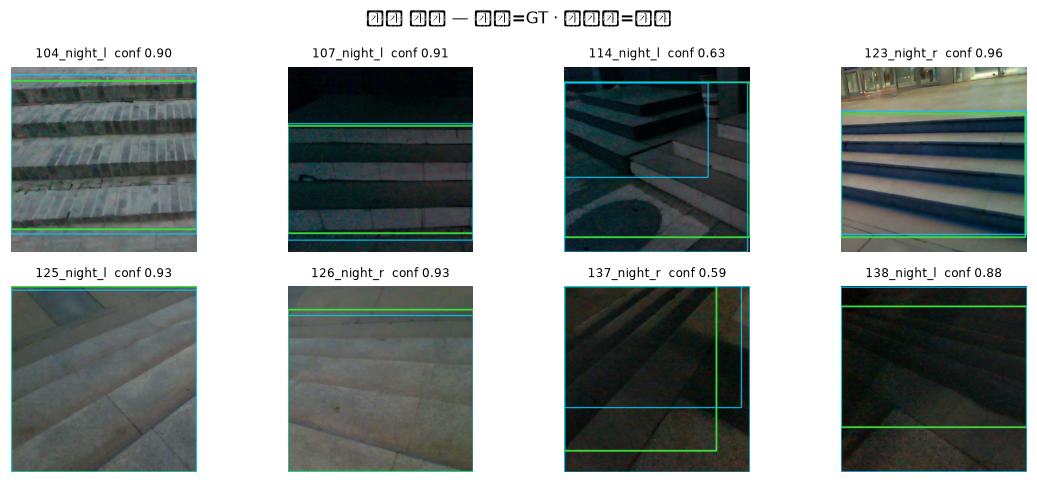

In [3]:
night_imgs = sorted((STAIRS_NIGHT / "images/val").glob("*"))[:8]
ims, tls = [], []
for p in night_imgs:
    rgb = load_rgb(p)
    h, w = rgb.shape[:2]
    gt = read_gt(STAIRS_NIGHT / "labels/val" / f"{p.stem}.txt", w, h, cls=STAIRS)
    r = model.predict(str(p), conf=0.25, imgsz=640, device=0, verbose=False)[0]
    pred = [tuple(int(v) for v in b.xyxy[0].tolist())
            for b in r.boxes if int(b.cls[0]) == STAIRS]
    conf = max((float(b.conf[0]) for b in r.boxes if int(b.cls[0]) == STAIRS), default=0.0)
    ims.append(draw(draw(rgb, gt, GT_COLOR, 3), pred, PRED_COLOR, 2))
    tls.append(f"{p.stem.replace('stair_color_', '')}  conf {conf:.2f}")
grid(ims, tls, ncol=4, suptitle="야간 계단 — 초록=GT · 하늘색=예측")

StairNet 은 **계단을 찍은 사진**이다. 화면 대부분이 계단이라, 위치를 크게 틀리지
않으면 IoU 가 쉽게 확보된다. 반면 서비스가 마주할 장면은 *거리를 걷다 계단을
만나는* 화면이다. **박스가 프레임에서 차지하는 면적**으로 두 세계의 거리를 재보자.

> **실측 (아래 셀)**: StairNet `stairs` 면적 중앙 **0.383** vs NightOwls `person`
> 면적 중앙 **0.0027** — **142배**다. 로그 스케일이어야 한 그림에 담긴다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  ax.legend(); fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\4019256375.py:27: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu S

C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cac

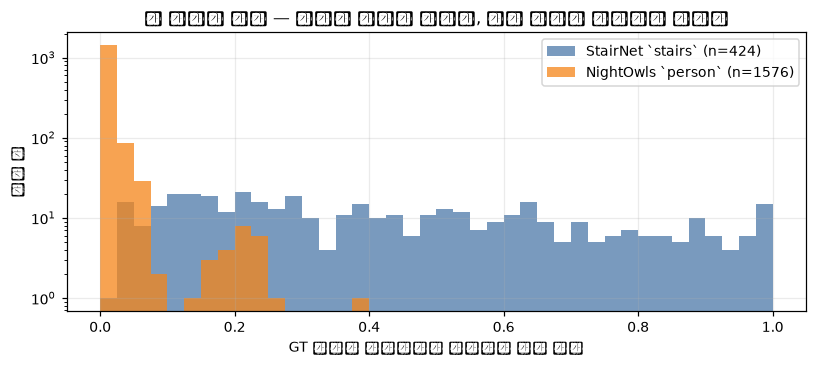

StairNet stairs 면적 중앙 0.383
NightOwls person 면적 중앙 0.0027

→ `stairs` 는 '계단을 찍은 사진'에서만 학습·평가됐다.
  **보행 중 멀리 있는 계단**(작은 박스)은 학습 데이터에 존재하지 않는다.


In [4]:
def area_fracs(img_dir, lab_dir, cls, limit=None):
    fr = []
    for p in sorted(Path(img_dir).glob("*"))[:limit]:
        lab = Path(lab_dir) / f"{p.stem}.txt"
        if not lab.is_file():
            continue
        for row in lab.read_text(encoding="utf-8").splitlines():
            if not row.strip() or int(float(row.split()[0])) != cls:
                continue
            _, _, _, bw, bh = (float(v) for v in row.split()[:5])
            fr.append(bw * bh)          # 정규화 좌표 → 그대로 면적 비율
    return np.array(fr)

stair_night = area_fracs(STAIRS_NIGHT / "images/val", STAIRS_NIGHT / "labels/val", STAIRS)
stair_day = area_fracs(STAIRS_DAY / "images/val", STAIRS_DAY / "labels/val", STAIRS)
person_no = area_fracs(NO34 / "images/val", NO34 / "labels/val", PERSON)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bins = np.linspace(0, 1, 41)
ax.hist(np.concatenate([stair_night, stair_day]), bins=bins, alpha=.75,
        label=f"StairNet `stairs` (n={len(stair_night)+len(stair_day)})", color="#4C78A8")
ax.hist(person_no, bins=bins, alpha=.75,
        label=f"NightOwls `person` (n={len(person_no)})", color="#F58518")
ax.set_xlabel("GT 박스가 프레임에서 차지하는 면적 비율")
ax.set_ylabel("박스 수"); ax.set_yscale("log")
ax.set_title("두 세계의 거리 — 계단은 화면을 채우고, 야간 거리의 보행자는 점이다")
ax.legend(); fig.tight_layout(); plt.show()

print(f"StairNet stairs 면적 중앙 {np.median(np.concatenate([stair_night, stair_day])):.3f}")
print(f"NightOwls person 면적 중앙 {np.median(person_no):.4f}")
print("\n→ `stairs` 는 '계단을 찍은 사진'에서만 학습·평가됐다.")
print("  **보행 중 멀리 있는 계단**(작은 박스)은 학습 데이터에 존재하지 않는다.")

## 3. ★★ 야간 거리 오탐 0.2% 의 두 얼굴

`C4b`(채택 런 `c4b_loli0`) 이후 NightOwls 야간 거리에서 `stairs` 오탐은
**0.2%**(2/1,001장) 다. 좋은 소식처럼 보이지만 읽는 법이 둘이다.

- (A) **헛보지 않는다** — 계단이 아닌 것을 계단이라 하지 않는다 ✅
- (B) **거리 장면에서는 아예 발화하지 않는다** — 진짜 계단이 나와도 못 찾을 수 있다 ⚠️

임계값(conf)을 낮춰가며 가른다. (A) 라면 낮은 임계에서도 거의 안 나오고,
**(B) 라면 억눌린 응답이 임계를 낮추는 순간 드러난다.**

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\3690320776.py:18: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\3690320776.py:18: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\3690320776.py:18: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\3690320776.py:18: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\3690320776.py:18: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
C:\Users\Publi

C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cac

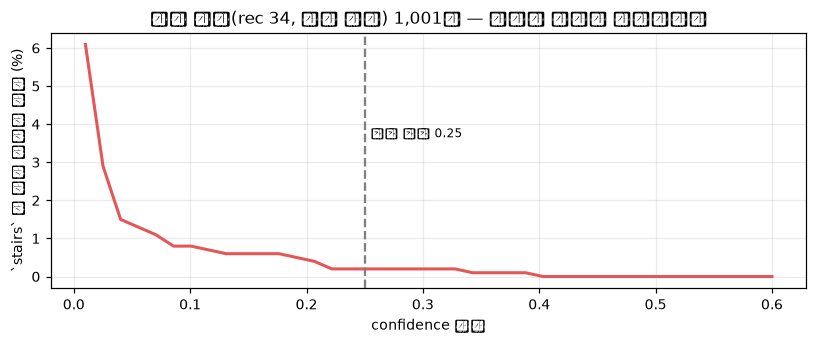

  conf >= 0.25:  0.20%  (2장)
  conf >= 0.10:  0.80%  (8장)
  conf >= 0.05:  1.40%  (14장)
  conf >= 0.01:  6.09%  (61장)

최대 conf 0.396 · 0 이 아닌 응답이 있는 이미지 61장


In [5]:
# 한 번만 매우 낮은 임계로 돌리고, 이미지별 stairs 최대 confidence 를 모아 재사용한다
imgs = sorted((NO34 / "images/val").glob("*"))
best_conf = []
for r in model.predict(source=[str(p) for p in imgs], conf=0.01, imgsz=640,
                       device=0, stream=True, verbose=False):
    c = [float(b.conf[0]) for b in r.boxes if int(b.cls[0]) == STAIRS] if r.boxes is not None else []
    best_conf.append(max(c) if c else 0.0)
best_conf = np.array(best_conf)

ths = np.linspace(0.01, 0.6, 40)
rate = [(best_conf >= t).mean() for t in ths]

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(ths, np.array(rate) * 100, lw=2, color="#E45756")
ax.axvline(0.25, ls="--", c="gray"); ax.text(0.255, max(rate) * 60, "판정 임계 0.25", fontsize=8)
ax.set_xlabel("confidence 임계"); ax.set_ylabel("`stairs` 가 나온 이미지 비율 (%)")
ax.set_title(f"야간 거리(rec 34, 계단 없음) {len(imgs):,}장 — 임계를 낮추면 발화하는가")
fig.tight_layout(); plt.show()

for t in (0.25, 0.10, 0.05, 0.01):
    print(f"  conf >= {t:.2f}: {(best_conf >= t).mean():6.2%}  ({(best_conf >= t).sum():,}장)")
print(f"\n최대 conf {best_conf.max():.3f} · 0 이 아닌 응답이 있는 이미지 {(best_conf > 0).sum():,}장")

> ### 관측 결과 (2026-08-02) — **(A) 에 가깝다**
>
> | 임계 | `stairs` 가 나온 이미지 |
> |---|---|
> | 0.25 (판정 임계) | 0.2% (2장) |
> | 0.10 | 0.8% (8장) |
> | 0.05 | 1.4% (14장) |
> | 0.01 | 6.1% (61장) |
>
> **임계를 25배 낮춰도 6% 뿐이고, 야간 거리 1,001장에서 최대 confidence 가 0.396 을
> 넘지 않는다.** 즉 모델이 계단 비슷한 것을 *강하게 보고도 눌러둔* 상태가 아니다 —
> 거리 장면에서 `stairs` 응답 자체가 조용하다. (B)"아예 발화하지 않는다"의 극단적
> 형태는 아니고, **(A)"헛보지 않는다"에 가깝다.**
>
> ⚠️ **그래도 (B) 를 완전히 배제하지는 못한다.** rec 34 에는 *진짜 계단이 한 번도
> 나오지 않기* 때문에, "계단이 없어서 조용한 것"과 "거리 장면이면 조용한 것"을
> 이 데이터로는 가를 수 없다. 판별은 **계단이 있는 야간 거리 장면**, 즉 `C2`
> 자체 촬영에서만 가능하다.

## 4. ★★ ②를 앞단에 붙이면 오탐이 되살아난다

`C7` 실측: 무처리 **0.1%** → `D1A1+bf` **5.7%** (57배). `C4b` 가 0 으로 만들어 둔
결함이 전처리 한 번에 돌아온다. 무엇을 계단으로 착각하는지 실물로 본다.

② 적용본에서 `stairs` 오탐 이미지 57 / 1,001  (5.7%)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\201204148

C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cac

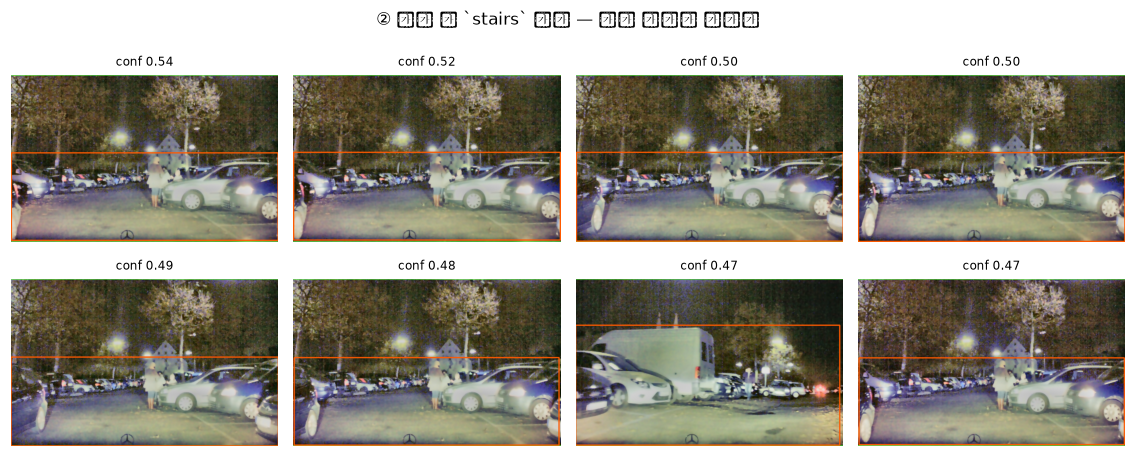

In [6]:
assert NO34_ARM.exists(), (
    f"없다: {NO34_ARM}\n먼저: uv run python scripts/arm_detect_eval.py")

arm_imgs = sorted((NO34_ARM / "images/val").glob("*"))
fps = []
for p, r in zip(arm_imgs, model.predict(source=[str(q) for q in arm_imgs], conf=0.25,
                                        imgsz=640, device=0, stream=True, verbose=False)):
    b = [(float(x.conf[0]), tuple(int(v) for v in x.xyxy[0].tolist()))
         for x in (r.boxes or []) if int(x.cls[0]) == STAIRS]
    if b:
        fps.append((p, max(b)[0], [x[1] for x in b]))
fps.sort(key=lambda t: -t[1])
print(f"② 적용본에서 `stairs` 오탐 이미지 {len(fps):,} / {len(arm_imgs):,}"
      f"  ({len(fps)/len(arm_imgs):.1%})")

ims, tls = [], []
for p, c, boxes in fps[:8]:
    ims.append(draw(load_rgb(p), boxes, FP_COLOR, 3))
    tls.append(f"conf {c:.2f}")
if ims:
    grid(ims, tls, ncol=4, suptitle="② 적용 후 `stairs` 오탐 — 전부 계단이 아니다")

### 4-1. 같은 장면, 처리 전후 나란히

**같은 프레임인데 ② 를 거치면 계단이 생겨난다.** 왼쪽(원본)에서는 잡히지 않던 것이
오른쪽(② 적용)에서 잡힌다면, 원인은 장면이 아니라 **전처리가 만든 톤·엣지**다.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\2012041488.py:81: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32828\201204

C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50812 (\N{HANGUL SYLLABLE OEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Local\uv\cache\archive-v0\6FNYdGUMUNMHb9BQ\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


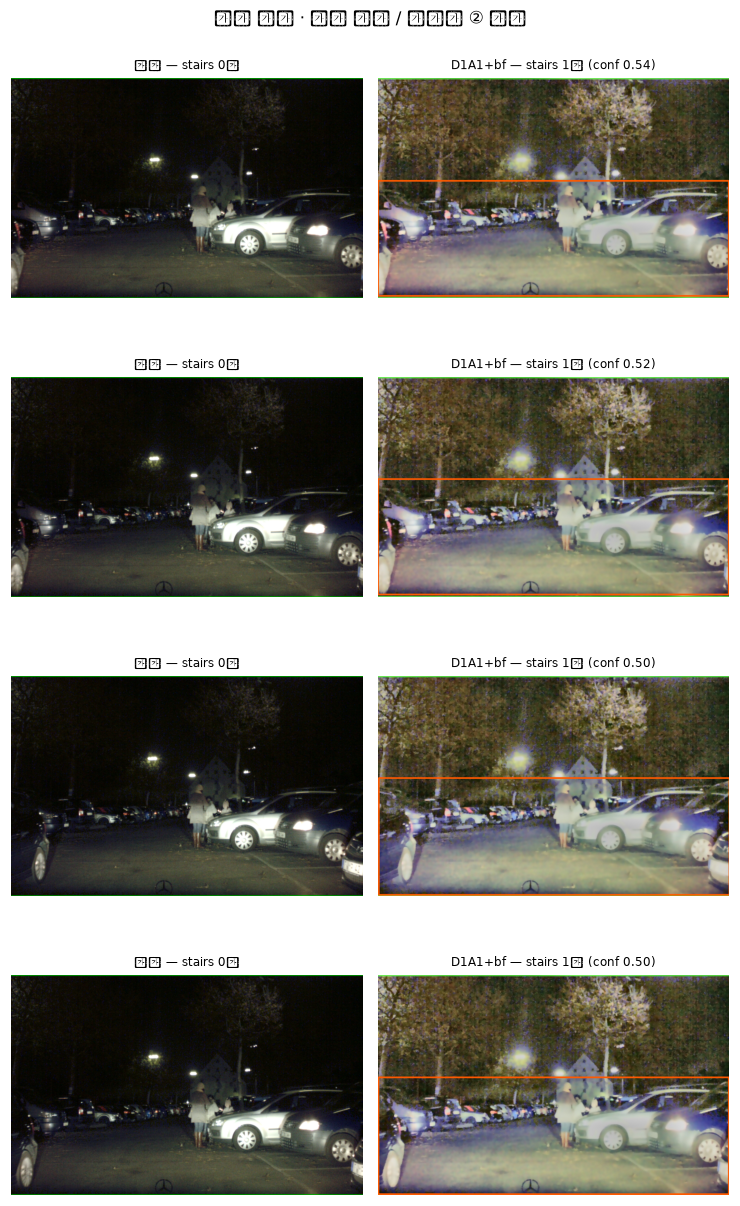

In [7]:
pairs = []
for p, c, boxes in fps[:4]:
    orig = NO34 / "images/val" / f"{p.stem}.png"
    if not orig.is_file():
        cand = list((NO34 / "images/val").glob(f"{p.stem}.*"))
        orig = cand[0] if cand else None
    if orig is None:
        continue
    r0 = model.predict(str(orig), conf=0.25, imgsz=640, device=0, verbose=False)[0]
    b0 = [tuple(int(v) for v in x.xyxy[0].tolist())
          for x in (r0.boxes or []) if int(x.cls[0]) == STAIRS]
    pairs.append((draw(load_rgb(orig), b0, FP_COLOR, 3), f"원본 — stairs {len(b0)}건",
                  draw(load_rgb(p), boxes, FP_COLOR, 3), f"D1A1+bf — stairs {len(boxes)}건 (conf {c:.2f})"))

ims = [im for a, ta, b, tb in pairs for im in (a, b)]
tls = [t for a, ta, b, tb in pairs for t in (ta, tb)]
if ims:
    grid(ims, tls, ncol=2, size=3.4, suptitle="같은 장면 · 왼쪽 원본 / 오른쪽 ② 적용")

## 5. 정리 — 무엇이 검증됐고 무엇이 안 됐는가

| 필요한 능력 | 상태 | 근거 |
|---|---|---|
| 계단 사진에서 계단 찾기 (야간 포함) | ✅ **된다** — 야간 mAP50 0.993 · recall 0.987 | 1절 |
| 계단 없는 야간 거리에서 헛보지 않기 | ✅ 오탐 0.2% (단 해석 주의) | 3절 |
| **보행 중 멀리 있는 계단** 찾기 | ❌ **측정 불가 — 데이터에 없다** | 2절 (면적 분포) |
| 부분 가림·측면 각도의 계단 | ❌ 측정 불가 | 2절 |
| ② 를 앞단에 붙였을 때 | ⚠️ **오탐 0.1% → 5.7%** | 4절 · [detection.md 7장](../docs/detection.md) |
| 일반 장애물(볼라드·전봇대 등) | ❌ **클래스 자체가 없다** | `person`·`stairs` 둘뿐 |

### 결론

> **"저조도 계단 탐지"는 저조도가 문제가 아니었다. 도메인이 문제다.**

어둠은 넘었다(야간 ≥ 주간). 남은 것은 **"계단을 찍은 사진"과 "걷다 만나는 계단"
사이의 거리**이고, 그것을 메울 수 있는 데이터는 지금 없다.

- 🔴 **`C2` 자체 야간 촬영이 유일한 해법이다.** 3절의 (A)/(B) 모호성도, 2절의 면적
  분포 격차도, 촬영 없이는 풀리지 않는다
- 🗣️ **`C3` 라벨 정의(회의 안건 4)를 촬영 전에 확정할 것** — 사후 변경 시 전량 재라벨링
- 🗣️ 일반 장애물 클래스 추가 여부 — 일정상 **추가하지 않는 쪽**을 권한다